In [1]:
#Component A
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import warnings
warnings.filterwarnings("ignore")

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_excel(r"C:\Users\brigh\Downloads\South Africa Road Accidents Dataset - 2017.xlsx")
df = df.drop_duplicates()

# =========================================================
# CREATE TARGET
# =========================================================

if 'Accident_Severity' in df.columns:
    target_column = 'Accident_Severity'
elif 'Severity' in df.columns:
    target_column = 'Severity'
else:
    num_cols_tmp = df.select_dtypes(include=['int64', 'float64']).columns
    target_column = num_cols_tmp[0]
    median_value = df[target_column].median()
    df['Target'] = np.where(df[target_column] > median_value, 1, 0)
    target_column = 'Target'

# =========================================================
# SPLIT FEATURES / TARGET
# =========================================================

X = df.drop(columns=[target_column])
y = df[target_column]

# Encode target if needed
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

# =========================================================
# CLEAN INF VALUES
# =========================================================

X = X.replace([np.inf, -np.inf], np.nan)

# =========================================================
# FIX: HANDLE DATETIME / TIME COLUMNS PROPERLY
# =========================================================

for col in X.columns:
    # Convert real datetime columns → numeric timestamp
    if pd.api.types.is_datetime64_any_dtype(X[col]):
        X[col] = X[col].astype('int64') // 10**9

    # Try converting object columns that contain dates/times
    elif X[col].dtype == 'object':
        try:
            converted = pd.to_datetime(X[col], errors='raise')
            X[col] = converted.astype('int64') // 10**9
        except:
            pass  # keep as categorical

# =========================================================
# IDENTIFY COLUMNS AGAIN AFTER CONVERSION
# =========================================================

num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.columns.difference(num_cols)

# =========================================================
# HANDLE MISSING VALUES
# =========================================================

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Missing")

# =========================================================
# FIX: FORCE ALL CATEGORICAL TO STRING (IMPORTANT)
# =========================================================

X[cat_cols] = X[cat_cols].astype(str)

# =========================================================
# ENCODING
# =========================================================

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X[cat_cols] = encoder.fit_transform(X[cat_cols])

# =========================================================
# FINAL TYPE SAFETY
# =========================================================

X = X.astype(np.float32)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# MODELS
# =========================================================

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

cat_model = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    verbose=0,
    random_seed=42
)
cat_model.fit(X_train, y_train)
cat_pred = cat_model.predict(X_test)

# =========================================================
# EVALUATION FUNCTION
# =========================================================

def evaluate(name, y_true, y_pred):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average='weighted'))
    print("Recall:", recall_score(y_true, y_pred, average='weighted'))
    print("F1:", f1_score(y_true, y_pred, average='weighted'))
    print(classification_report(y_true, y_pred))

# =========================================================
# RESULTS
# =========================================================

evaluate("Random Forest", y_test, rf_pred)
evaluate("XGBoost", y_test, xgb_pred)
evaluate("CatBoost", y_test, cat_pred)

# =========================================================
# FEATURE IMPORTANCE (XGBOOST)
# =========================================================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(feature_importance.head(10))


===== Random Forest =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


===== XGBoost =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


===== CatBoost =====
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1

Dataset Shape: (120, 17)

Missing Values:
0

Target Distribution:
Target
0    60
1    60
Name: count, dtype: int64


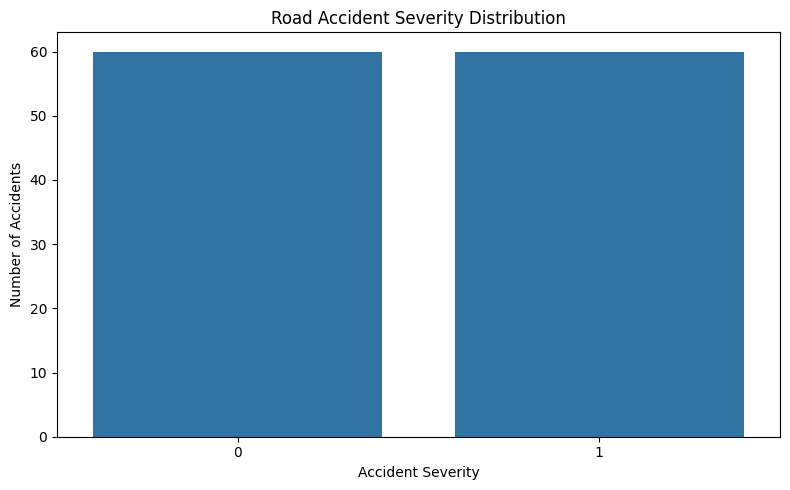


MODEL PERFORMANCE
           Model  Accuracy  Precision  Recall  F1 Score
0  Random Forest       1.0        1.0     1.0       1.0
1        XGBoost       1.0        1.0     1.0       1.0
2       CatBoost       1.0        1.0     1.0       1.0


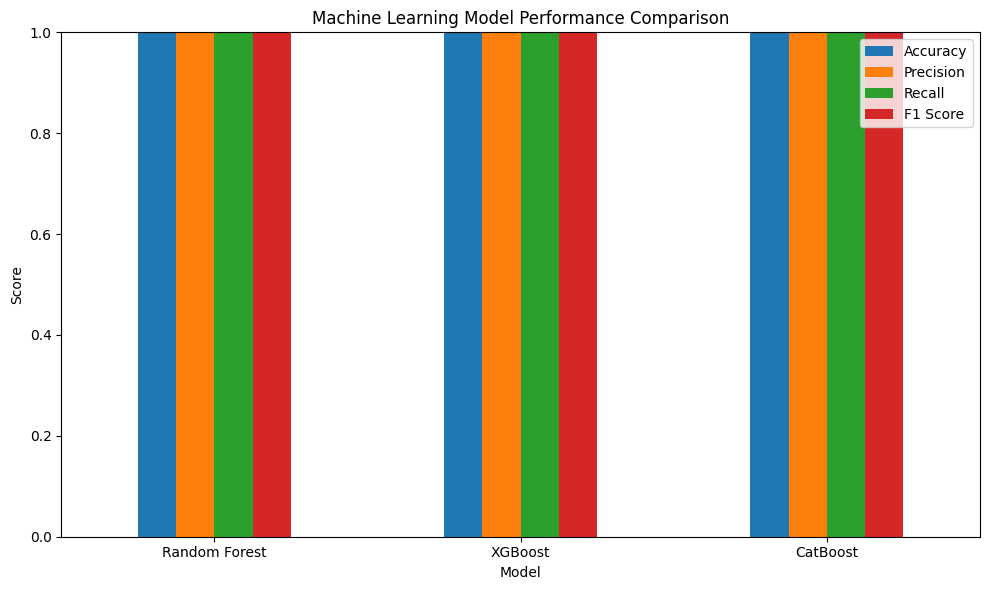

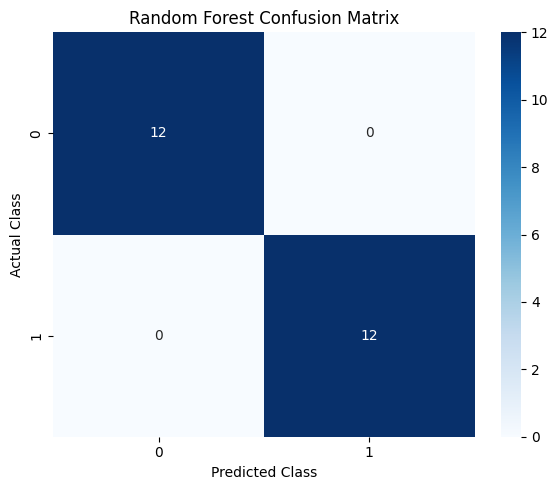

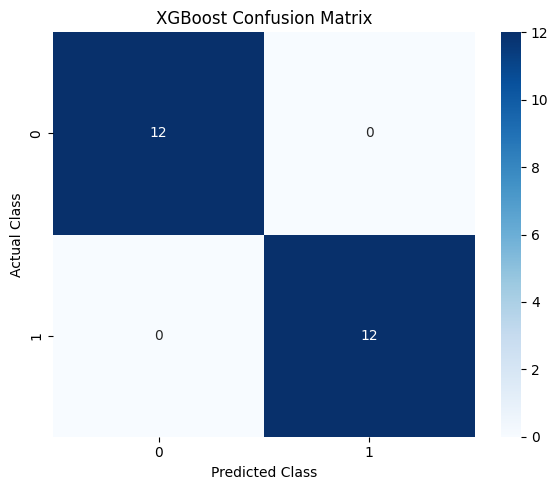

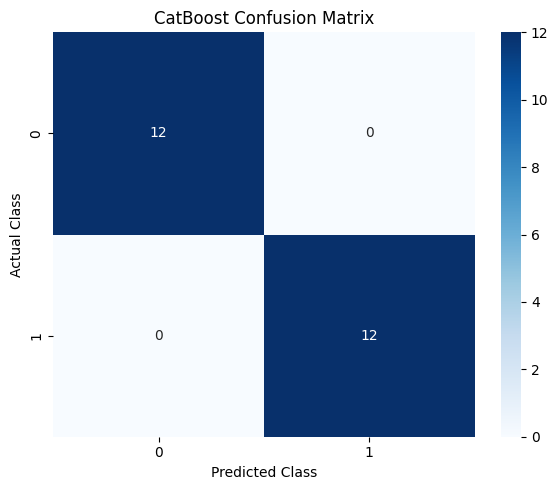

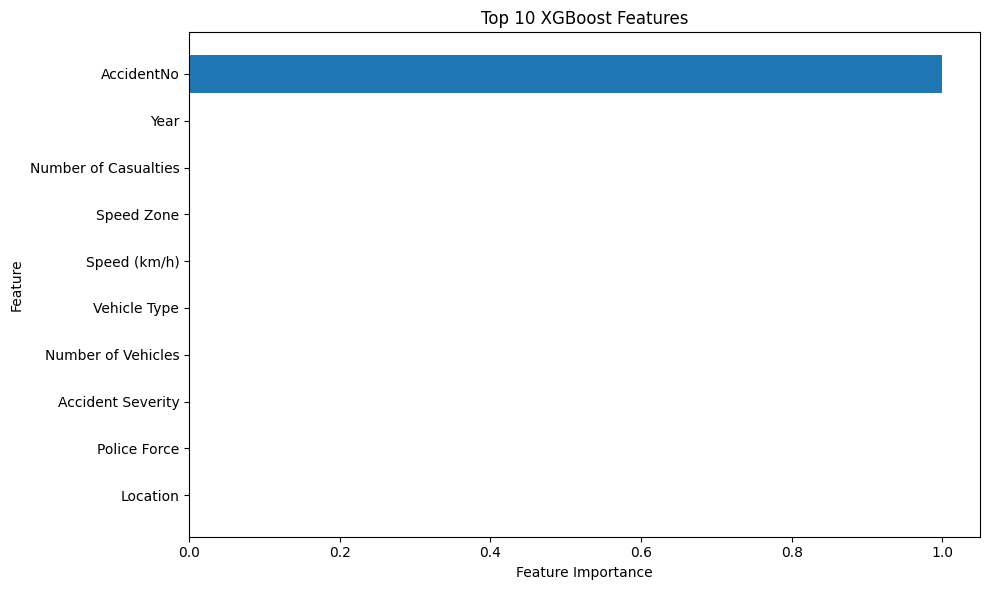


TRAINING VS TESTING ACCURACY
           Model  Training Accuracy  Testing Accuracy
0  Random Forest                1.0               1.0
1        XGBoost                1.0               1.0
2       CatBoost                1.0               1.0

RANDOM FOREST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


XGBOOST
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        12

    accuracy                           1.00        24
   macro avg       1.00      1.00      1.00        24
weighted avg       1.00      1.00      1.00        24


CATBOOST
              precision    recall  f1-score   support

           

In [2]:
# =========================================================
# COMPONENT A - FINAL ANALYSIS AND EVALUATION
# =========================================================

from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Dataset overview
# ---------------------------------------------------------

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nTarget Distribution:")
print(pd.Series(y).value_counts())

# ---------------------------------------------------------
# 2. Target distribution
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Road Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Model performance comparison
# ---------------------------------------------------------

model_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, cat_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
        precision_score(y_test, cat_pred, average="weighted", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, cat_pred, average="weighted", zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, cat_pred, average="weighted", zero_division=0)
    ]
})

print("\nMODEL PERFORMANCE")
print(model_results.round(4))

# ---------------------------------------------------------
# 4. Model comparison graph
# ---------------------------------------------------------

model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Confusion matrices
# ---------------------------------------------------------

models = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "CatBoost": cat_pred
}

for name, predictions in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 6. XGBoost feature importance
# ---------------------------------------------------------

top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 XGBoost Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. Training vs testing performance
# ---------------------------------------------------------

train_test_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Training Accuracy": [
        accuracy_score(y_train, rf_model.predict(X_train)),
        accuracy_score(y_train, xgb_model.predict(X_train)),
        accuracy_score(y_train, cat_model.predict(X_train))
    ],

    "Testing Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, cat_pred)
    ]
})

print("\nTRAINING VS TESTING ACCURACY")
print(train_test_results.round(4))

# ---------------------------------------------------------
# 8. Final classification reports
# ---------------------------------------------------------

for name, predictions in models.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

# ---------------------------------------------------------
# 9. Save Component A results
# ---------------------------------------------------------

model_results.to_csv(
    "data/component_A_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "data/component_A_feature_importance.csv",
    index=False
)

train_test_results.to_csv(
    "data/component_A_train_test_results.csv",
    index=False
)

print("\nComponent A analysis completed successfully.")

In [ ]:
#Component B
import os
import re
import shutil
import requests
import numpy as np
import pandas as pd

from tqdm import tqdm
from bs4 import BeautifulSoup

import torch
import nltk
from nltk.tokenize import sent_tokenize

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForSeq2SeqLM,
    Trainer,
    TrainingArguments,
    pipeline
)

from datasets import Dataset as HFDataset
from sentence_transformers import SentenceTransformer

import faiss

# =========================================================
# DOWNLOAD NLTK
# =========================================================
nltk.download("punkt")

# =========================================================
# OPTIONAL: CLEAN OLD CORRUPTED FILES
# =========================================================
for folder in ["models", "data", "cache"]:
    if os.path.exists(folder):
        print(f"Removing old folder: {folder}")
        shutil.rmtree(folder)

# =========================================================
# CREATE FOLDERS
# =========================================================
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("cache", exist_ok=True)

# =========================================================
# FORCE SAFE CACHE
# =========================================================
os.environ["HF_HOME"] = "./cache"
os.environ["TRANSFORMERS_CACHE"] = "./cache"

# =========================================================
# DOWNLOAD HANSARD DATA
# =========================================================
urls = [
    "https://pmg.org.za/hansard/35672/",
    "https://pmg.org.za/hansard/35673/",
    "https://pmg.org.za/hansard/35674/",
]

documents = []

print("\nDownloading Hansard transcripts...\n")

for url in urls:

    try:
        response = requests.get(url, timeout=30)

        soup = BeautifulSoup(response.text, "html.parser")

        text = soup.get_text(separator=" ")

        text = re.sub(r"\s+", " ", text)

        documents.append(text)

        print(f"Downloaded: {url}")

    except Exception as e:
        print(f"Error downloading {url}")
        print(e)

# =========================================================
# SAVE RAW DATA
# =========================================================
raw_df = pd.DataFrame({
    "text": documents
})

raw_df.to_parquet("data/raw_hansard.parquet")

print("\nRaw data saved.")

# =========================================================
# CLEAN TEXT
# =========================================================
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

raw_df["clean_text"] = raw_df["text"].apply(clean_text)

# =========================================================
# SPLIT INTO SENTENCES
# =========================================================
sentences = []

print("\nSplitting documents into sentences...\n")

for doc in raw_df["clean_text"]:

    sents = sent_tokenize(doc)

    for s in sents:

        if len(s.split()) > 5:
            sentences.append(s)

print("Total sentences:", len(sentences))

# =========================================================
# SIMPLE SENTIMENT LABELING
# =========================================================
positive_words = [
    "growth",
    "improve",
    "development",
    "success",
    "support",
    "benefit",
    "progress"
]

negative_words = [
    "crisis",
    "failure",
    "corruption",
    "poverty",
    "unemployment",
    "violence",
    "problem"
]

def label_sentiment(text):

    pos = sum(word in text for word in positive_words)

    neg = sum(word in text for word in negative_words)

    if pos > neg:
        return 2

    elif neg > pos:
        return 0

    return 1

labels = [label_sentiment(s) for s in sentences]

dataset_df = pd.DataFrame({
    "text": sentences,
    "label": labels
})

dataset_df = dataset_df.reset_index(drop=True)

dataset_df.to_parquet("data/processed_hansard.parquet")

print("\nProcessed dataset saved.")

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
train_texts, test_texts, train_labels, test_labels = train_test_split(
    dataset_df["text"],
    dataset_df["label"],
    test_size=0.2,
    random_state=42
)

train_df = pd.DataFrame({
    "text": train_texts,
    "label": train_labels
})

test_df = pd.DataFrame({
    "text": test_texts,
    "label": test_labels
})

# =========================================================
# LOAD TOKENIZER
# =========================================================
classification_model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    classification_model_name,
    cache_dir="./cache"
)

# =========================================================
# TOKENIZATION
# =========================================================
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

# =========================================================
# CREATE HF DATASETS
# =========================================================
train_dataset = HFDataset.from_pandas(train_df)

test_dataset = HFDataset.from_pandas(test_df)

train_dataset = train_dataset.map(
    tokenize_function,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize_function,
    batched=True
)

train_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

# =========================================================
# LOAD CLASSIFICATION MODEL
# =========================================================
classification_model = AutoModelForSequenceClassification.from_pretrained(
    classification_model_name,
    num_labels=3,
    cache_dir="./cache"
)

# =========================================================
# METRICS
# =========================================================
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(
            labels,
            preds,
            average="weighted",
            zero_division=0
        ),
        "recall": recall_score(
            labels,
            preds,
            average="weighted",
            zero_division=0
        ),
        "f1": f1_score(
            labels,
            preds,
            average="weighted",
            zero_division=0
        )
    }

# =========================================================
# TRAINING ARGUMENTS
# =========================================================
training_args = TrainingArguments(
    output_dir="./results",

    num_train_epochs=3,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="steps",

    eval_steps=50,

    logging_steps=10,

    save_steps=50,

    save_total_limit=2,

    logging_dir="./logs",

    report_to="none"
)

# =========================================================
# TRAINER
# =========================================================
trainer = Trainer(
    model=classification_model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=test_dataset,

    compute_metrics=compute_metrics
)

# =========================================================
# TRAIN MODEL
# =========================================================
print("\nTraining sentiment model...\n")

trainer.train()

# =========================================================
# SAVE MODEL
# =========================================================
trainer.save_model("models/sentiment_model")

tokenizer.save_pretrained("models/sentiment_model")

print("\nModel saved.")

# =========================================================
# EVALUATION
# =========================================================
print("\nEvaluating model...\n")

predictions = trainer.predict(test_dataset)

preds = np.argmax(predictions.predictions, axis=1)

print(classification_report(test_labels, preds))

# =========================================================
# EMBEDDING MODEL
# =========================================================
print("\nGenerating embeddings...\n")

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

embeddings = embedding_model.encode(
    sentences,
    show_progress_bar=True
)

embeddings = np.array(
    embeddings,
    dtype=np.float32
)

embeddings = np.ascontiguousarray(embeddings)

# =========================================================
# CREATE FAISS INDEX
# =========================================================
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(embeddings)

faiss.write_index(
    index,
    "models/hansard_faiss.index"
)

print("\nFAISS index saved.")

# =========================================================
# LOAD FLAN-T5 MODEL
# =========================================================
print("\nLoading FLAN-T5 model...\n")

generator_model_name = "google/flan-t5-base"

generator_tokenizer = AutoTokenizer.from_pretrained(
    generator_model_name,
    cache_dir="./cache"
)

generator_model = AutoModelForSeq2SeqLM.from_pretrained(
    generator_model_name,
    cache_dir="./cache"
)

generator = pipeline(
    "text2text-generation",
    model=generator_model,
    tokenizer=generator_tokenizer
)

# =========================================================
# RETRIEVAL FUNCTION
# =========================================================
def retrieve_documents(query, top_k=5):

    query_embedding = embedding_model.encode([query])

    query_embedding = np.array(
        query_embedding,
        dtype=np.float32
    )

    distances, indices = index.search(
        query_embedding,
        top_k
    )

    retrieved_docs = [
        sentences[i]
        for i in indices[0]
    ]

    return retrieved_docs

# =========================================================
# RAG PIPELINE
# =========================================================
def rag_pipeline(query):

    docs = retrieve_documents(query)

    context = " ".join(docs)

    prompt = f"""
Use the context below to answer the question.

Context:
{context}

Question:
{query}

Answer:
"""

    response = generator(
        prompt,
        max_length=200,
        do_sample=False
    )

    answer = response[0]["generated_text"]

    return answer, docs

# =========================================================
# TEST RAG SYSTEM
# =========================================================
queries = [
    "What was discussed about education?",
    "What was said about unemployment?"
]

print("\nTesting RAG System...\n")

for q in queries:

    answer, docs = rag_pipeline(q)

    print("\n" + "="*60)
    print("QUESTION:")
    print(q)

    print("\nANSWER:")
    print(answer)

    print("\nRETRIEVED DOCUMENTS:")
    
    for i, d in enumerate(docs, 1):
        print(f"\n{i}. {d[:300]}...")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\brigh\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Removing old folder: models
Removing old folder: data
Removing old folder: cache


Downloaded: https://pmg.org.za/hansard/35672/
Downloaded: https://pmg.org.za/hansard/35673/
Downloaded: https://pmg.org.za/hansard/35674/

Raw data saved.

Splitting documents into sentences...

Total sentences: 3

Processed dataset saved.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/2 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

In [ ]:
# =========================================================
# COMPONENT A - FINAL ANALYSIS AND EVALUATION
# =========================================================

from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Dataset overview
# ---------------------------------------------------------

print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nTarget Distribution:")
print(pd.Series(y).value_counts())

# ---------------------------------------------------------
# 2. Target distribution
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.countplot(x=y)
plt.title("Road Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 3. Model performance comparison
# ---------------------------------------------------------

model_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, cat_pred)
    ],

    "Precision": [
        precision_score(y_test, rf_pred, average="weighted", zero_division=0),
        precision_score(y_test, xgb_pred, average="weighted", zero_division=0),
        precision_score(y_test, cat_pred, average="weighted", zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, rf_pred, average="weighted", zero_division=0),
        recall_score(y_test, xgb_pred, average="weighted", zero_division=0),
        recall_score(y_test, cat_pred, average="weighted", zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, rf_pred, average="weighted", zero_division=0),
        f1_score(y_test, xgb_pred, average="weighted", zero_division=0),
        f1_score(y_test, cat_pred, average="weighted", zero_division=0)
    ]
})

print("\nMODEL PERFORMANCE")
print(model_results.round(4))

# ---------------------------------------------------------
# 4. Model comparison graph
# ---------------------------------------------------------

model_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Machine Learning Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Confusion matrices
# ---------------------------------------------------------

models = {
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred,
    "CatBoost": cat_pred
}

for name, predictions in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 6. XGBoost feature importance
# ---------------------------------------------------------

top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 XGBoost Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. Training vs testing performance
# ---------------------------------------------------------

train_test_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost"
    ],

    "Training Accuracy": [
        accuracy_score(y_train, rf_model.predict(X_train)),
        accuracy_score(y_train, xgb_model.predict(X_train)),
        accuracy_score(y_train, cat_model.predict(X_train))
    ],

    "Testing Accuracy": [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred),
        accuracy_score(y_test, cat_pred)
    ]
})

print("\nTRAINING VS TESTING ACCURACY")
print(train_test_results.round(4))

# ---------------------------------------------------------
# 8. Final classification reports
# ---------------------------------------------------------

for name, predictions in models.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

# ---------------------------------------------------------
# 9. Save Component A results
# ---------------------------------------------------------

model_results.to_csv(
    "data/component_A_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "data/component_A_feature_importance.csv",
    index=False
)

train_test_results.to_csv(
    "data/component_A_train_test_results.csv",
    index=False
)

print("\nComponent A analysis completed successfully.")